In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

df=pd.read_excel('C:/Users/woody/Desktop/ALY6130/In-Class_Assignment.xlsx', sheet_name="RiskRegister_")
df

,Risk #,The Risk of/That,Likelihood Score,Impact Score
0,R1,A cybersecurity breach,4,2
1,R2,Operational downtime,2,2
2,R3,Workforce resistance to new systems,6,8
3,R4,Data privacy non-compliance,1,9
4,R5,Reputational loss,3,8
5,R6,System integration failure,7,7
6,R7,Inventory mismanagement due to automation errors,3,7
7,R8,Supplier failure to meet ESG standards,3,9
8,R9,Overreliance on few tech vendors,1,9
9,R10,Failure in AI-based demand forecasting,7,8


In [2]:
risk_df = df[['Risk #', 'The Risk of/That', 'Likelihood Score', 'Impact Score']].dropna()
risk_df.columns = ['Risk_ID', 'Risk_Description', 'Likelihood_Score', 'Impact_Score']

In [3]:
def classify_severity(row):
    if row['Likelihood_Score'] >= 7 and row['Impact_Score'] >= 5:
        return 'High'
    elif row['Likelihood_Score'] >= 5 or row['Impact_Score'] >= 3:
        return 'Medium'
    else:
        return 'Low'

risk_df['Severity_Label'] = risk_df.apply(classify_severity, axis=1)

## Risk Classification Rules

Severity levels are derived from likelihood and impact scores:

- **High**: `Likelihood ≥ 8` **and** `Impact ≥ 5`
- **Medium**: `Likelihood ≥ 5` **or** `Impact ≥ 3`
- **Low**: everything else

These labels are used as classification targets for the machine learning model.

---

## Model Overview

- **Model used**: RandomForestClassifier (100 trees, `random_state=42`)
- **Features**: `Likelihood Score`, `Impact Score`
- **Target**: `Severity_Label` (Low / Medium / High)
- **Validation**: 5-Fold Cross-Validation

### Cross-Validation Results
```plaintext
Mean Accuracy (5-Fold CV): 0.93
Fold Accuracies:
[1.         0.83333333 1.         1.         0.8       ]


c:\Users\woody\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Mean accuracy (5-fold CV): 0.93
Accuracy for each fold: [1.         0.83333333 1.         1.         0.8       ]


c:\Users\woody\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(



Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         4
         Low       0.67      1.00      0.80         4
      Medium       1.00      0.90      0.95        20

    accuracy                           0.93        28
   macro avg       0.89      0.97      0.92        28
weighted avg       0.95      0.93      0.93        28



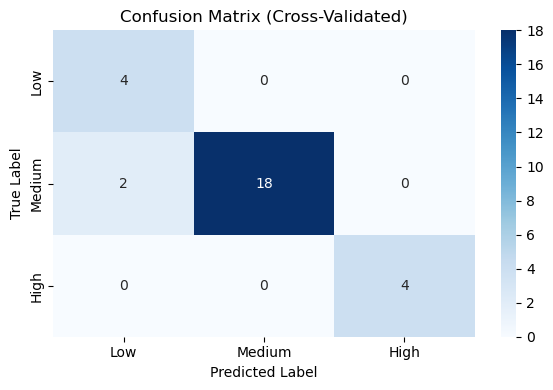

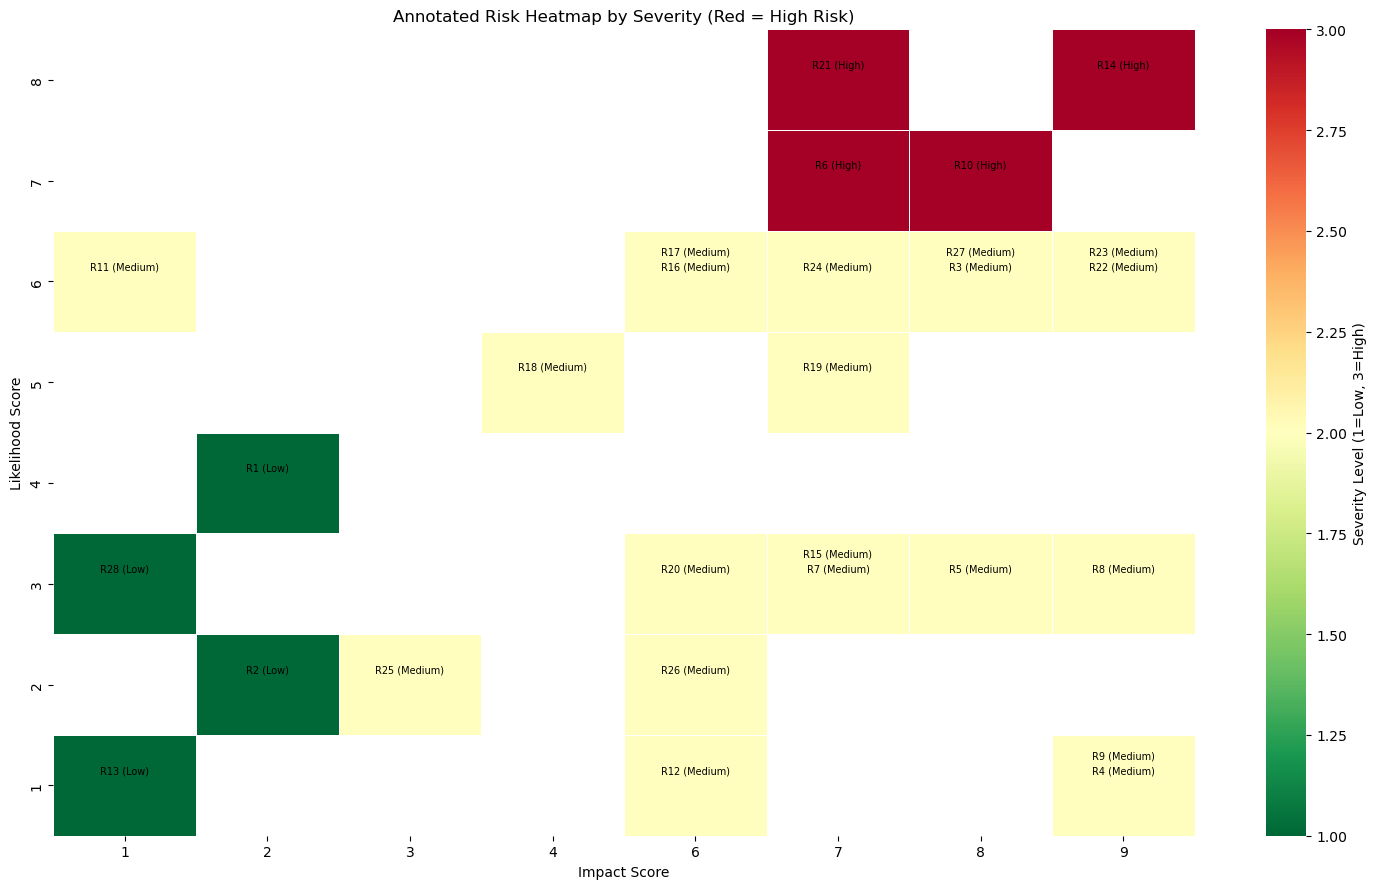

In [4]:
# === prepare train data ===
X = risk_df[['Likelihood_Score', 'Impact_Score']]
y = risk_df['Severity_Label']
model = RandomForestClassifier(n_estimators=100, random_state=42)

# === corss validation ===
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"Mean accuracy (5-fold CV): {scores.mean():.2f}")
print("Accuracy for each fold:", scores)

# prediction and classification report
y_pred_cv = cross_val_predict(model, X, y, cv=5)
print("\nClassification Report:")
print(classification_report(y, y_pred_cv))

# Confusion matrix plot
conf_matrix = confusion_matrix(y, y_pred_cv, labels=['Low', 'Medium', 'High'])
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])
plt.title("Confusion Matrix (Cross-Validated)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# === STEP 6: risk heatmap ===
severity_levels = {'Low': 1, 'Medium': 2, 'High': 3}
risk_df['Severity_Num'] = risk_df['Severity_Label'].map(severity_levels)
risk_df['Label'] =risk_df['Risk_ID'].astype(str) + ' (' + risk_df['Severity_Label'] + ')'

pivot_severity = risk_df.groupby(['Likelihood_Score', 'Impact_Score'])['Severity_Num'].max().unstack()
label_matrix = risk_df.groupby(['Likelihood_Score', 'Impact_Score'])['Label'] \
                      .apply(lambda x: '\n'.join(x)).unstack(fill_value='')

pivot_severity = pivot_severity.sort_index(ascending=False)
label_matrix = label_matrix.sort_index(ascending=False)

plt.figure(figsize=(15, 9))
ax = sns.heatmap(pivot_severity, cmap='RdYlGn_r', linewidths=0.5,
                 cbar_kws={'label': 'Severity Level (1=Low, 3=High)'})

for y in range(label_matrix.shape[0]):
    for x in range(label_matrix.shape[1]):
        text = label_matrix.iloc[y, x]
        if text:
            lines = text.split('\n')
            for i, line in enumerate(lines):
                ax.text(x + 0.5, y + 0.3 - 0.15 * i, line,
                        ha='center', va='top', fontsize=7, color='black')

plt.title("Annotated Risk Heatmap by Severity (Red = High Risk)")
plt.xlabel("Impact Score")
plt.ylabel("Likelihood Score")
plt.tight_layout()
plt.show()

## Confusion Matrix

Most Medium risks were classified correctly (18/20).

All High and Low risks were predicted perfectly or almost perfectly.

Slight misclassification occurred between Medium -> Low.


##  Summary

- The Random Forest model demonstrates strong performance with **93% average accuracy** across 5-fold cross-validation.
- Most risk categories are classified correctly, though minor imbalance still affects recall for some minority classes.
- The **risk heatmap** helps visualize severity distribution, making it easier to prioritize mitigation—especially for **High Likelihood + High Impact** risks in the top-right zone.
- This combined approach—**rule-based labeling**, **machine learning classification**, and **heatmap visualization**—provides both analytic insight and stakeholder-friendly communication.
- **Next**, we will select **four high-risk items** and apply **quantitative techniques (e.g., Monte Carlo simulation)** to estimate their financial or time-based impact and support deeper decision-making.


# Quantitative Risk

In [8]:
risks= {
    'R21': {'optimistic': 3000, 'most_likely': 8000, 'pessimistic': 30000},
    'R14': {'optimistic': 5000, 'most_likely': 15000, 'pessimistic': 45000},
    'R6' : {'optimistic': 2000, 'most_likely': 7000, 'pessimistic': 20000},
    'R10': {'optimistic': 1000, 'most_likely': 5000, 'pessimistic': 18000}
}

In [ ]:
from tqdm import tqdm
import pandas as pd
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt

# Risks 
risks = {
    'R21': {'optimistic': 3000, 'most_likely': 8000, 'pessimistic': 30000},
    'R14': {'optimistic': 5000, 'most_likely': 15000, 'pessimistic': 45000},
    'R6' : {'optimistic': 2000, 'most_likely': 7000, 'pessimistic': 20000},
    'R10': {'optimistic': 1000, 'most_likely': 5000, 'pessimistic': 18000}
}

# normal distribution
def run_normal_simulation(risks, iteration=10000):
    simulations = []
    for risk_id, values in tqdm(risks.items(), desc="Simulating (Normal)"):
        o = np.random.normal(loc=values['optimistic'], scale=500, size=iteration)
        m = np.random.normal(loc=values['most_likely'], scale=500, size=iteration)
        p = np.random.normal(loc=values['pessimistic'], scale=500, size=iteration)

        cost = (o + 4 * m + p) / 6
        df = pd.DataFrame({'Cost': cost})
        df['Risk_ID'] = risk_id
        df['Method'] = 'Normal'
        simulations.append(df)
    return pd.concat(simulations, ignore_index=True)

# ✅ beta distriution 
def run_beta_simulation(risks, iteration=10000, a=2, b=4):
    simulations = []
    for risk_id, values in tqdm(risks.items(), desc="Simulating (Beta)"):
    
        o_beta = beta.rvs(a, b, size=iteration)
        m_beta = beta.rvs(a, b, size=iteration)
        p_beta = beta.rvs(a, b, size=iteration)

        o = values['optimistic'] + o_beta * (values['most_likely'] - values['optimistic'])
        m = values['most_likely'] + m_beta * (values['pessimistic'] - values['most_likely'])
        p = values['most_likely'] + p_beta * (values['pessimistic'] - values['most_likely'])

        cost = (o + 4 * m + p) / 6
        df = pd.DataFrame({'Cost': cost})
        df['Risk_ID'] = risk_id
        df['Method'] = 'Beta'
        simulations.append(df)
    return pd.concat(simulations, ignore_index=True)

# exe
df_normal = run_normal_simulation(risks)
df_beta = run_beta_simulation(risks)

# combine
combined_df = pd.concat([df_normal, df_beta], ignore_index=True)
summary = combined_df.groupby(['Risk_ID', 'Method'])['Cost'].describe().round(2)
print(summary)


Simulating (Beta): 100%|██████████| 4/4 [00:00<00:00, 253.89it/s]

                  count      mean      std       min       25%       50%  \
Risk_ID Method                                                             
R10     Beta    10000.0   8174.53  1604.38   4600.88   6932.12   8011.88   
        Normal  10000.0   6498.36   348.66   5164.12   6267.08   6501.17   
R14     Beta    10000.0  22226.48  3751.75  14350.52  19345.73  21833.36   
        Normal  10000.0  18332.33   353.02  17046.53  18091.28  18333.45   
R21     Beta    10000.0  13580.98  2724.17   7513.56  11483.76  13279.30   
        Normal  10000.0  10829.37   354.75   9399.45  10589.29  10831.31   
R6      Beta    10000.0  10035.53  1581.55   6586.65   8810.46   9884.01   
        Normal  10000.0   8334.77   348.89   6822.09   8101.48   8335.34   

                     75%       max  
Risk_ID Method                      
R10     Beta     9258.56  13598.94  
        Normal   6731.36   7818.01  
R14     Beta    24794.38  36130.56  
        Normal  18573.89  19829.21  
R21     Beta    1

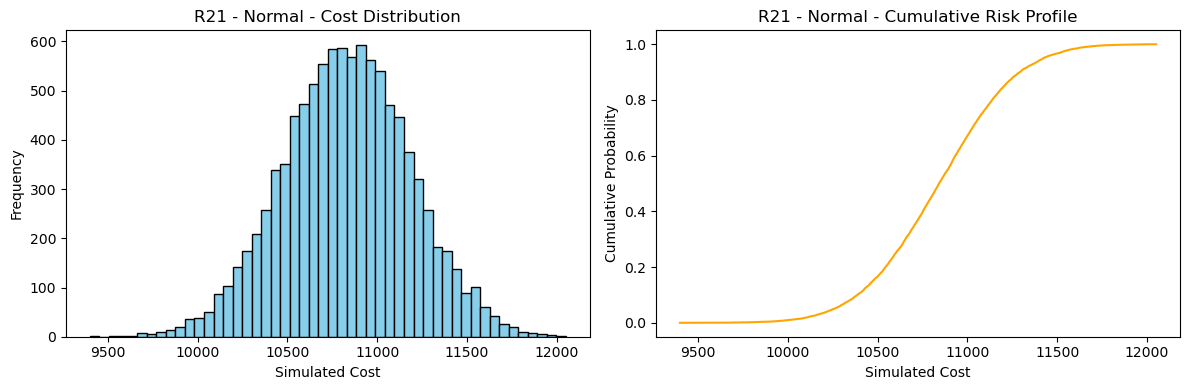

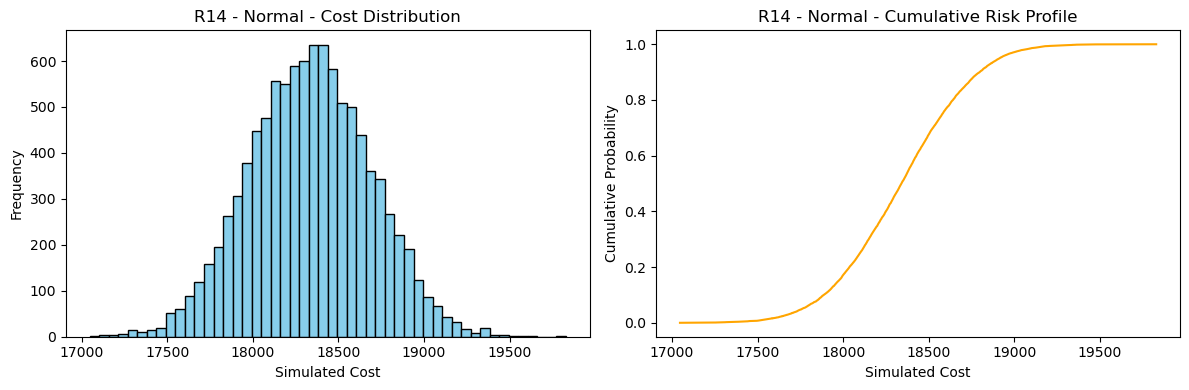

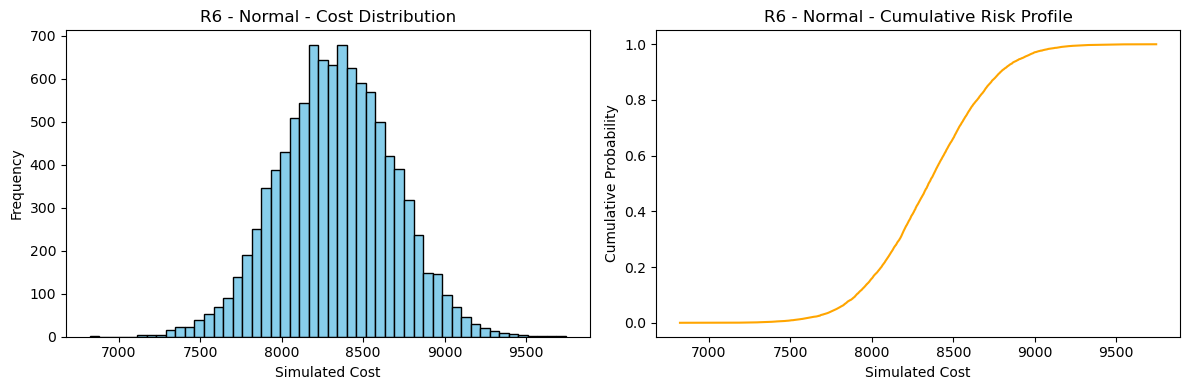

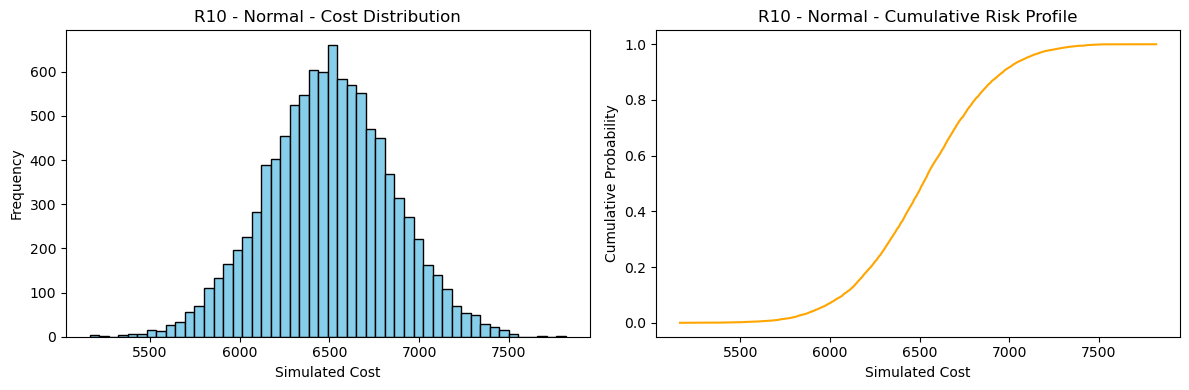

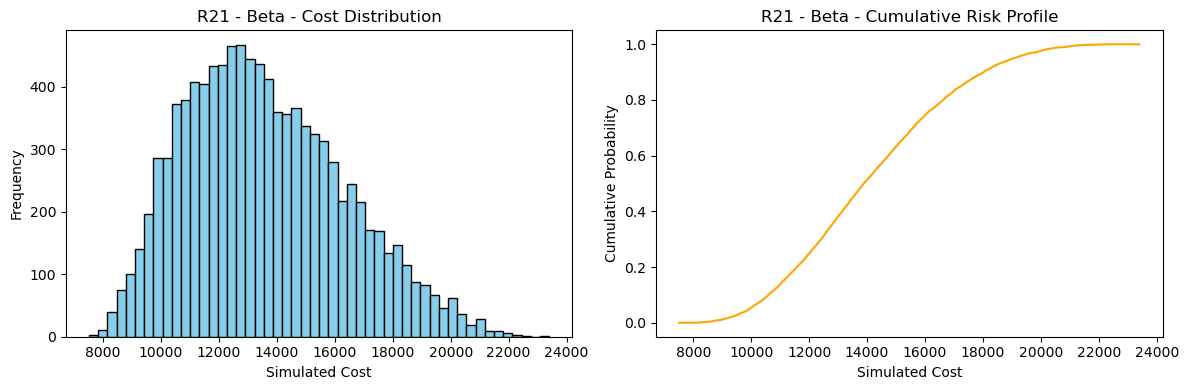

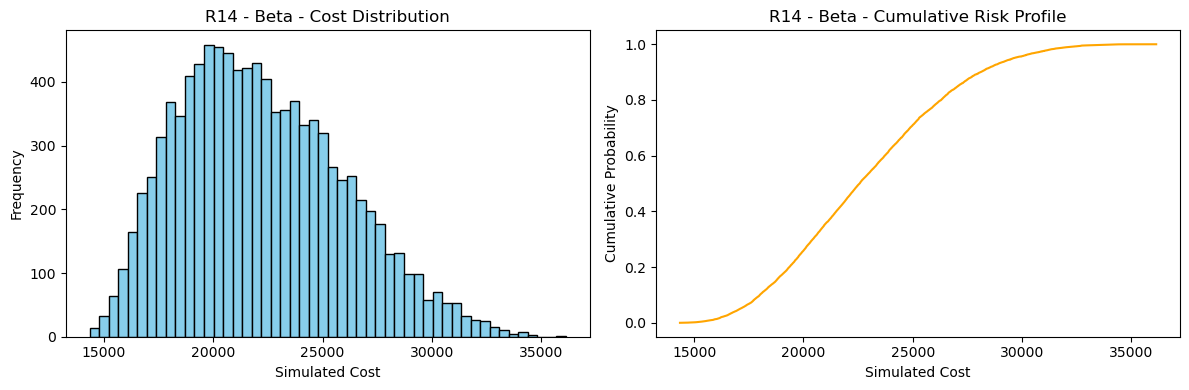

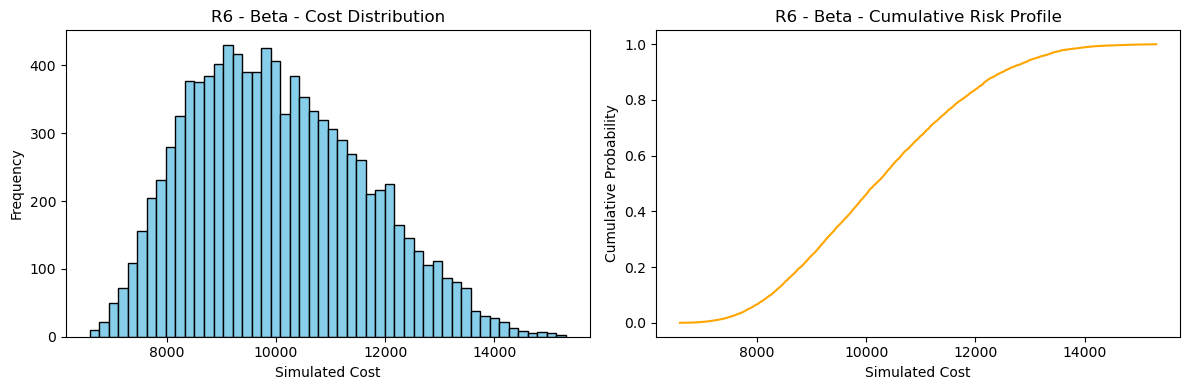

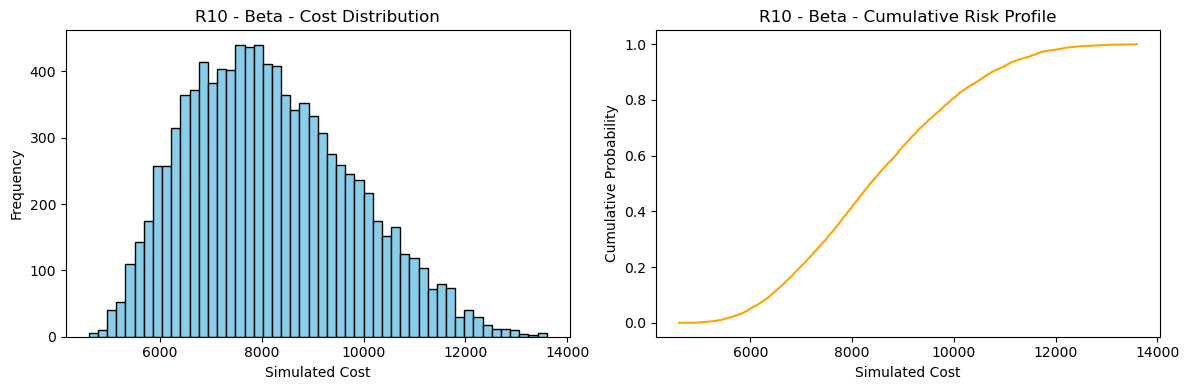

In [ ]:
# Risk 
risk_methods = combined_df[['Risk_ID', 'Method']].drop_duplicates()

for _, row in risk_methods.iterrows():
    risk_id = row['Risk_ID']
    method = row['Method']
    
    df = combined_df[(combined_df['Risk_ID'] == risk_id) & (combined_df['Method'] == method)].copy()
    df = df.sort_values('Cost')
    df['cumulative'] = df['Cost'].cumsum() / df['Cost'].sum()
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # histogram
    ax[0].hist(df['Cost'], bins=50, color='skyblue', edgecolor='black')
    ax[0].set_title(f"{risk_id} - {method} - Cost Distribution")
    ax[0].set_xlabel("Simulated Cost")
    ax[0].set_ylabel("Frequency")
    
    # CDF Cumulative Distribution Function
    ax[1].plot(df['Cost'], df['cumulative'], color='orange')
    ax[1].set_title(f"{risk_id} - {method} - Cumulative Risk Profile")
    ax[1].set_xlabel("Simulated Cost")
    ax[1].set_ylabel("Cumulative Probability")
    
    plt.tight_layout()
    plt.show()


### PERT (Three-Point Estimation) vs. Normal Mean

We explored two different modeling approaches for generating simulation inputs:

| Method | Description |
|--------|-------------|
| **PERT** | Uses *Three-Point Estimation* (Optimistic, Most Likely, Pessimistic) with weighted average formula: `(O + 4M + P)/6`. Often modeled using Beta distribution. |
| **Normal** | Assumes a symmetric distribution centered around a mean (e.g., the "optimistic" or "most likely" value), with standard deviation defining spread. |

PERT is better suited when the data is skewed or bounded (e.g., risk costs rarely go below zero but can spike upward), while Normal is ideal for symmetric uncertainty.

---


### Distribution Choice: Normal vs. Beta

We modeled each risk scenario using both **Normal distribution** and **Beta distribution**:

| Feature | Normal Distribution | Beta Distribution |
|---------|----------------------|-------------------|
| Shape | Symmetric (bell-shaped) | Skewed (typically right-skewed for cost) |
| Control | Mean & Std Dev | Min, Max, Most Likely |
| Tail Behavior | Limited extreme values | Can model long tails (rare but high costs) |
| Realism | Theoretical, simple | More realistic for real-world risks |

---


### For R21 Simulation Results

We compare the simulated cost outcomes of **R21** under both models:

#### R21 – Normal Distribution


- **Cost Distribution (left)**: Bell-shaped curve centered around ~$10,800.
- **Cumulative Risk Profile (right)**: Sharp S-curve, indicating concentrated outcomes.
- **Interpretation**: Cost is expected to fall in a narrow range, with few extreme outcomes.

#### R21 – Beta Distribution


- **Cost Distribution (left)**: Right-skewed curve, heavier tail toward high cost.
- **Cumulative Risk Profile (right)**: Slower climb indicates more spread in risk outcomes.
- **Interpretation**: Most costs are between $12,000–$15,000, but a small chance exists for extreme outcomes above $20,000.

---